In [5]:
from sklearn.model_selection import train_test_split
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

**Обработка датафреймов**

In [6]:
os.listdir('data/')
noise_data = 'data/dataFrameSets/test/'
ver_data_crawl = 'data/dataFrameSets/verified_data_crawl/'
ver_data = 'data/dataFrameSets/verified_data/'

video_paths = []
for folder in [noise_data, ver_data_crawl, ver_data]:
    video_paths.extend([os.path.join(folder, f) for f in os.listdir(folder)])

len(video_paths)

1632

In [7]:
paths_train, paths_test = train_test_split(video_paths, test_size=0.2, random_state=42)

len(paths_train), len(paths_test)

(1305, 327)

In [8]:
dfs = [pd.read_csv(f) for f in tqdm(paths_train)]
full_df = pd.concat(dfs, ignore_index=True)

print(full_df.shape)
print(full_df.memory_usage(deep=True).sum() / (1024**2), "MB")

100%|██████████████████████████████████████████████████████████████████████████████| 1305/1305 [00:36<00:00, 36.11it/s]


(8867, 992)
67.62091159820557 MB


In [9]:
print(full_df.isna().sum().sum())
print(full_df.isna().any().sum())
print(full_df.isna().any(axis=1).sum()) 
print(full_df.shape)

558558
891
1128
(8867, 992)


In [10]:
full_df.columns

Index(['nose_x_t0', 'nose_y_t0', 'nose_z_t0', 'left_eye_inner_x_t0',
       'left_eye_inner_y_t0', 'left_eye_inner_z_t0', 'left_eye_x_t0',
       'left_eye_y_t0', 'left_eye_z_t0', 'left_eye_outer_x_t0',
       ...
       'right_heel_y_t9', 'right_heel_z_t9', 'left_foot_index_x_t9',
       'left_foot_index_y_t9', 'left_foot_index_z_t9', 'right_foot_index_x_t9',
       'right_foot_index_y_t9', 'right_foot_index_z_t9', 'delta_t', 'label'],
      dtype='object', length=992)

In [11]:
y_train = full_df['label']

drop_landmarks = [
    'nose',
    'left_eye_inner', 'left_eye', 'left_eye_outer',
    'right_eye_inner', 'right_eye', 'right_eye_outer',
    'mouth_left', 'mouth_right',
    'left_thumb_2', 'right_thumb_2'
]
cols_to_keep = [c for c in full_df.columns if not any(lm in c for lm in drop_landmarks)]
full_df = full_df.loc[:, cols_to_keep]

In [32]:
full_df['frames'] = (((~full_df.isna()).sum(axis=1)-2)/66).astype(int)

In [45]:
X_train = full_df.drop('label', axis=1)
X_train

,left_ear_x_t0,left_ear_y_t0,left_ear_z_t0,right_ear_x_t0,right_ear_y_t0,right_ear_z_t0,left_shoulder_x_t0,left_shoulder_y_t0,left_shoulder_z_t0,right_shoulder_x_t0,...,right_heel_y_t9,right_heel_z_t9,left_foot_index_x_t9,left_foot_index_y_t9,left_foot_index_z_t9,right_foot_index_x_t9,right_foot_index_y_t9,right_foot_index_z_t9,delta_t,frames
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.206769,0.303356,0.486300,1.097964,0.574114,0.477733,1.213837,0.205665,0.066733,10
1,0.441181,0.082911,-0.066965,0.436673,0.089447,-0.262563,0.434329,0.252048,0.062834,0.404064,...,1.257014,0.066458,0.472608,1.173798,0.297044,0.473677,1.259071,-0.009155,0.066733,10
2,0.467303,0.110003,-0.054710,0.462975,0.108563,-0.272148,0.441561,0.251938,0.046801,0.408225,...,1.248856,0.249819,0.466518,1.146940,0.494061,0.463784,1.237758,0.162859,0.066733,10
3,0.434069,0.082349,-0.113428,0.429589,0.089558,-0.305001,0.426738,0.253475,0.012415,0.391949,...,1.151447,0.216670,0.453816,1.110657,0.378522,0.440878,1.157101,0.114509,0.066733,10
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.190654,0.294498,0.487573,1.078156,0.565951,0.471889,1.197516,0.192108,0.066733,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8862,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.739642,0.335781,0.207295,0.937855,1.162139,0.240275,1.010988,0.276864,0.166833,10
8863,0.508246,-0.175694,-0.175796,0.459811,-0.166100,-0.766806,0.483052,0.216103,0.288244,0.377448,...,2.550473,-0.427073,0.670494,2.621837,-0.706100,0.468551,2.779507,-0.795276,0.166833,10
8864,0.441744,-0.048725,-0.316098,0.342936,0.035246,0.010833,0.663765,0.258635,-0.325327,0.306355,...,2.613066,0.381392,0.827628,2.626804,0.245643,0.640890,2.697411,-0.079071,0.166833,10
8865,0.552536,0.466871,0.472741,0.510175,0.455155,0.539420,0.578784,0.587817,0.395996,0.454262,...,1.426285,0.023966,0.430316,1.521077,-0.271229,0.307055,1.491691,-0.113590,0.166667,10


In [61]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [48]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_train, len(y_train)

(array([ 0,  0,  0, ..., 16,  7,  7], dtype=int64), 8867)

**Инициализация LightBGM модели и сетки для GridSearch**

In [ ]:
modelLGBM = lgb.LGBMClassifier(
    random_state=42,
    n_jobs=-1,
    verbose=1,
    importance_type='gain',
    objective='multiclass',
    class_weight='balanced'
)

In [67]:
param_grid_big = {
    'num_leaves': [15, 31, 63],
    'max_depth': [5, 7, 9],
    'min_child_samples': [20, 30],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [0, 0.1]
}

param_grid_small = {
    'num_leaves': [31, 63],
    'max_depth': [5, 7],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200]
}

In [68]:
def perform_grid_search(X, y, model, param_grid, cv_folds=5):
    
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=9)
    
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=2,
        return_train_score=True
    )
    
    n_combinations = np.prod([len(v) for v in param_grid.values()])
    print(f"combinations: {n_combinations}")
    
    grid_search.fit(X, y)
    
    print(f"best params: {grid_search.best_params_}")
    print(f"best score: {grid_search.best_score_}")
    
    return grid_search

In [69]:
grid_search = perform_grid_search(X_train, y_train, modelLGBM, param_grid_small)

combinations: 16
Fitting 5 folds for each of 16 candidates, totalling 80 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.039404 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 168337
[LightGBM] [Info] Number of data points in the train set: 8867, number of used features: 662
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091043
[LightGBM] [Info] Start training from score -3.091043
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

**Оценка модели на тестовой выборке**

In [71]:
dfs_test_small = [pd.read_csv(f) for f in tqdm(paths_test)]
df_test = pd.concat(dfs_test_small, ignore_index=True)

print(df_test.shape)
print(df_test.memory_usage(deep=True).sum() / (1024**2), "MB")

100%|████████████████████████████████████████████████████████████████████████████████| 327/327 [00:08<00:00, 36.57it/s]

(2194, 992)
16.73132610321045 MB


In [72]:
y_test = df_test['label']

drop_landmarks = [
    'nose',
    'left_eye_inner', 'left_eye', 'left_eye_outer',
    'right_eye_inner', 'right_eye', 'right_eye_outer',
    'mouth_left', 'mouth_right',
    'left_thumb_2', 'right_thumb_2'
]
cols_to_keep = [c for c in df_test.columns if not any(lm in c for lm in drop_landmarks)]
df_test = df_test.loc[:, cols_to_keep]

In [73]:
df_test['frames'] = (((~df_test.isna()).sum(axis=1)-2)/66).astype(int)

In [74]:
X_test = df_test.drop('label', axis=1)
X_test

,left_ear_x_t0,left_ear_y_t0,left_ear_z_t0,right_ear_x_t0,right_ear_y_t0,right_ear_z_t0,left_shoulder_x_t0,left_shoulder_y_t0,left_shoulder_z_t0,right_shoulder_x_t0,...,right_heel_y_t9,right_heel_z_t9,left_foot_index_x_t9,left_foot_index_y_t9,left_foot_index_z_t9,right_foot_index_x_t9,right_foot_index_y_t9,right_foot_index_z_t9,delta_t,frames
0,0.723089,0.353335,-0.018321,0.708107,0.348120,0.147912,0.740275,0.500258,-0.113476,0.693972,...,0.699850,-0.031627,0.232112,0.536318,-0.241005,0.240758,0.534659,-0.091455,0.133467,10
1,0.710538,0.354280,-0.030742,0.697460,0.348052,0.130211,0.725261,0.496475,-0.119129,0.688667,...,0.711255,0.099027,0.208165,0.569743,-0.083872,0.232518,0.571618,0.078419,0.133467,10
2,0.711680,0.343177,-0.014056,0.686813,0.335400,0.148921,0.720183,0.480928,-0.106776,0.680604,...,0.691057,-0.009562,0.224907,0.538976,-0.207932,0.246097,0.537129,-0.054705,0.133467,10
3,0.708400,0.362109,0.001917,0.697760,0.360304,0.153329,0.730443,0.490159,-0.090599,0.693297,...,0.728950,0.139603,0.208525,0.575122,-0.151985,0.231787,0.582022,0.121606,0.133467,10
4,0.723458,0.352132,-0.034790,0.706668,0.349026,0.138837,0.742320,0.495050,-0.121013,0.708987,...,0.700568,-0.043236,0.236214,0.542059,-0.224620,0.232902,0.533957,-0.095161,0.133467,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2189,0.557411,0.165900,-0.113522,0.535664,0.160205,-0.219421,0.571292,0.268259,0.002066,0.492770,...,0.856478,-0.024310,0.580211,0.891100,0.056247,0.508240,0.884350,-0.155257,0.160000,10
2190,0.560492,0.165049,-0.163642,0.538183,0.160718,-0.264499,0.576252,0.275073,-0.053271,0.493919,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.160000,2
2191,0.576655,0.250818,0.029240,0.530758,0.260536,-0.132353,0.609338,0.418725,0.234294,0.478897,...,1.357076,-0.091864,0.712766,1.349087,0.219247,0.648130,1.460133,-0.142630,0.133467,10
2192,0.574158,0.245452,0.083556,0.525652,0.252998,-0.047363,0.608698,0.432766,0.224050,0.488110,...,1.323542,-0.060554,0.724611,1.319743,0.277396,0.632683,1.470192,-0.058823,0.133467,10


In [75]:
y_test = le.fit_transform(y_test)
y_test, len(y_test)

(array([16, 16, 16, ...,  2,  2,  2]), 2194)

**Метрики и confusion matrix**

In [79]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = grid_search.predict(X_test)

y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)

print(classification_report(y_test_labels, y_pred_labels))
confusion_matrix = confusion_matrix(y_test, y_pred)

                     precision    recall  f1-score   support

barbell biceps curl       0.66      0.76      0.71        99
        bench press       0.70      0.64      0.67        88
  chest fly machine       0.80      0.91      0.85        85
           deadlift       0.69      0.74      0.71        81
decline bench press       0.80      0.86      0.83       141
        hammer curl       0.73      0.65      0.69       105
         hip thrust       0.85      0.93      0.89        98
incline bench press       0.66      0.80      0.72        64
       lat pulldown       0.80      0.67      0.73        83
      lateral raise       0.90      0.76      0.82        79
      leg extension       0.96      0.90      0.93       149
         leg raises       0.82      0.83      0.82        90
              plank       0.98      0.98      0.98       259
            pull Up       0.90      0.75      0.81       118
            push-up       0.99      0.90      0.94       111
  romanian deadlift    

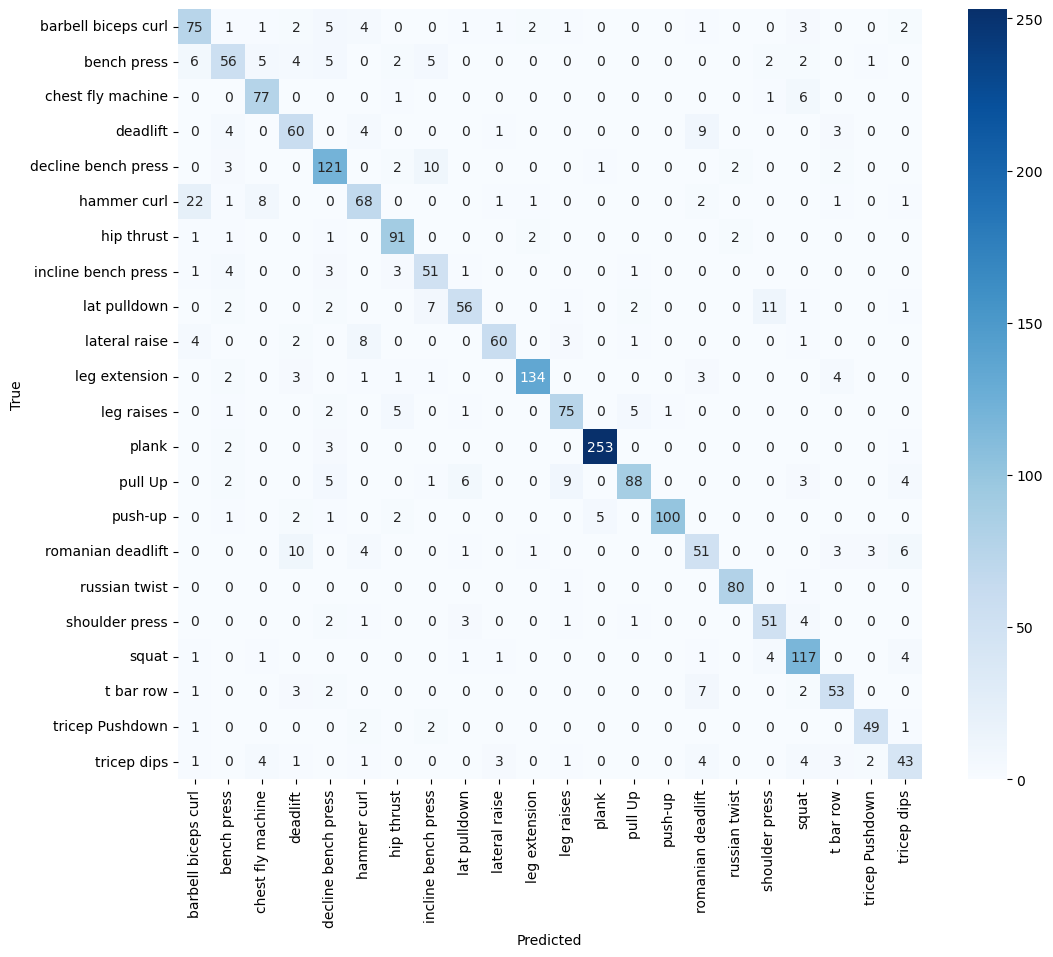

In [81]:
import seaborn as sns

labels = le.classes_

plt.figure(figsize=(12,10))
sns.heatmap(confusion_matrix, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

**Сохранение обученной модели**

In [82]:
from joblib import dump, load

dump(grid_search.best_estimator_, 'model/lgbm_model.joblib')

['model/lgbm_model.joblib']

In [89]:
grid_search.best_estimator_.booster_.save_model('model/lgbm_model.txt')